#                                                     **MID TERM VIVA 2025-ACS**

## **1)Using the Dataset "Education.csv" to perform statistical Analysis**

#### *Import the libraries:*

In [2]:
import pandas as pd   
import numpy as np    
import matplotlib.pyplot as plt 
import seaborn as sns  
from scipy import stats  


#### *displaying the first file rows importing "Education.csv"*

In [4]:
df_edu = pd.read_csv("Education.csv")
df_edu.head()

,AC_YEAR,STATCD,DISTCD,STATNAME,DISTNAME,DISTRICTS,BLOCKS,VILLAGES,CLUSTERS,TOTPOPULAT,...,UUNI_ALL,UUNI_SC,UUNI_ST,TOTCLS1G,TOTCLS2G,TOTCLS3G,TOTCLS4G,TOTCLS5G,TOTCLS6G,TOTCLS7G
0,2015-16,1,101,JAMMU & KASHMIR,KUPWARA,1,13,391,104,875564.0,...,21322,26,2594,3489,5315,27,62,23,852,239
1,2015-16,1,102,JAMMU & KASHMIR,BARAMULA,1,18,678,144,1015503.0,...,17307,0,1571,4127,5800,210,53,30,1665,360
2,2015-16,1,103,JAMMU & KASHMIR,SRINAGAR,1,8,94,65,1269751.0,...,5444,31,408,817,3284,886,11,0,2873,40
3,2015-16,1,104,JAMMU & KASHMIR,BADGAM,1,13,523,104,735753.0,...,12469,18,857,2290,3837,119,45,8,1035,325
4,2015-16,1,105,JAMMU & KASHMIR,PULWAMA,1,8,359,64,570060.0,...,7408,17,855,1688,2584,151,67,5,1101,209


#### *basic Information of Dataset:*

In [6]:
print(df_edu.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 680 entries, 0 to 679
Columns: 819 entries, AC_YEAR to TOTCLS7G
dtypes: float64(13), int64(803), object(3)
memory usage: 4.2+ MB
None


In [7]:
print(df_edu.describe())

           STATCD       DISTCD  DISTRICTS      BLOCKS     VILLAGES  \
count  680.000000   680.000000      680.0  680.000000   680.000000   
mean    17.292647  1745.976471        1.0   10.760294   874.614706   
std      9.451743   944.257509        0.0    9.585360   622.711657   
min      1.000000   101.000000        1.0    1.000000     6.000000   
25%      9.000000   937.750000        1.0    5.000000   390.750000   
50%     18.000000  1823.500000        1.0    8.000000   785.500000   
75%     24.000000  2413.250000        1.0   13.000000  1204.250000   
max     36.000000  3610.000000        1.0   66.000000  3963.000000   

         CLUSTERS    TOTPOPULAT   P_URB_POP  POPULATION_0_6  GROWTHRATE  ...  \
count  680.000000  6.340000e+02  631.000000    6.330000e+02  634.000000  ...   
mean   121.226471  1.899024e+06   24.819255    2.494264e+05   17.627886  ...   
std     94.040172  1.547475e+06   19.093744    1.985112e+05   11.346020  ...   
min      1.000000  7.948000e+03  -25.350000    1.

#### *checking the null values:*

In [9]:
print(df_edu.isnull())
print(df_edu.isnull().sum())

     AC_YEAR  STATCD  DISTCD  STATNAME  DISTNAME  DISTRICTS  BLOCKS  VILLAGES  \
0      False   False   False     False     False      False   False     False   
1      False   False   False     False     False      False   False     False   
2      False   False   False     False     False      False   False     False   
3      False   False   False     False     False      False   False     False   
4      False   False   False     False     False      False   False     False   
..       ...     ...     ...       ...       ...        ...     ...       ...   
675    False   False   False     False     False      False   False     False   
676    False   False   False     False     False      False   False     False   
677    False   False   False     False     False      False   False     False   
678    False   False   False     False     False      False   False     False   
679    False   False   False     False     False      False   False     False   

     CLUSTERS  TOTPOPULAT  

#### *Check no. of rows and columns:*

In [12]:
print(df_edu.shape)

(680, 819)


## **2) Explore and visualize the Dataset using plots for "Education.csv"**
#### **Using first 10 rows**

### QUANTATIVE DATA:

#### *`Histogram:`*

#### **PLOTTING A HISTOGRAM FOR THE TOTAL POPULATION COLUMN:**

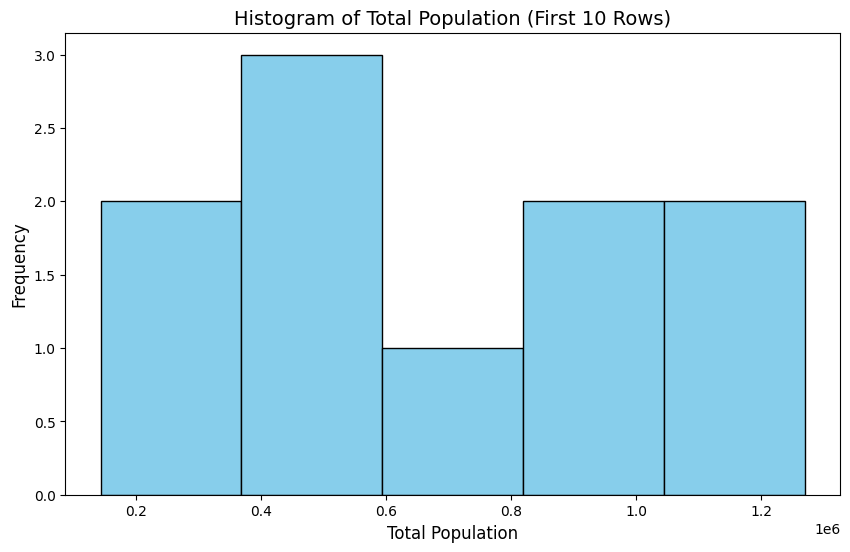

In [19]:
population_data = df_edu["TOTPOPULAT"].head(10).dropna()  
plt.figure(figsize=(10, 6))  
plt.hist(population_data, bins=5, color='skyblue', edgecolor='black')  
# Labels and title
plt.xlabel("Total Population", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of Total Population (First 10 Rows)", fontsize=14)

plt.show()


#### `*bar Graph:*`

#### **BAR GRAPH BETWEEN TOTAL POPULATION AND THE DISTRICT**

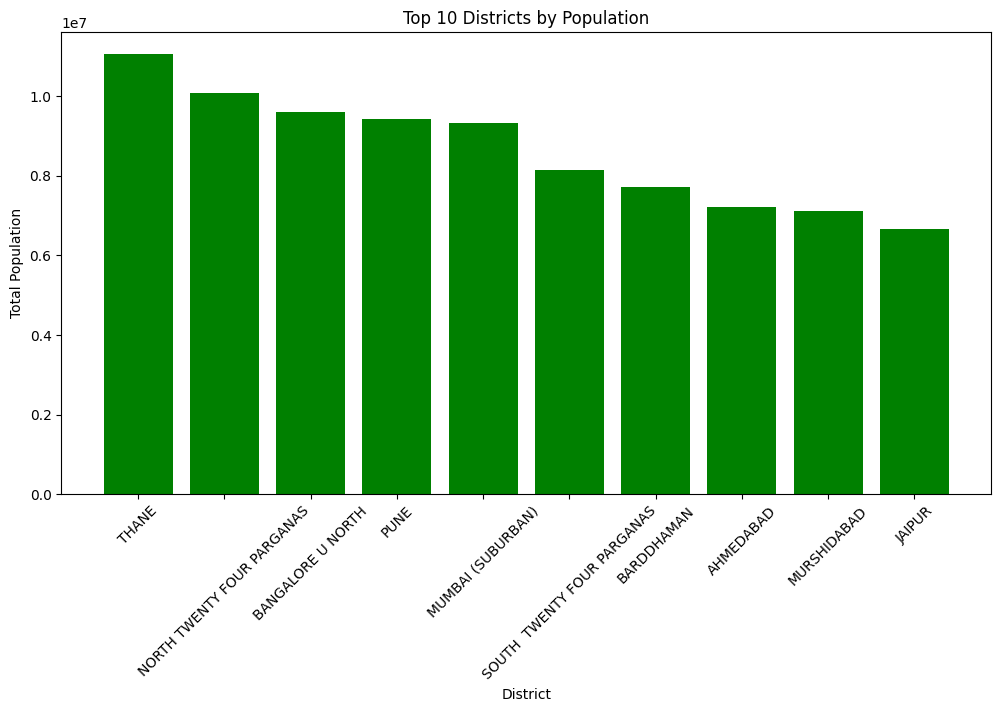

In [22]:
districts = df_edu.nlargest(10, "TOTPOPULAT")

plt.figure(figsize=(12, 6))
plt.bar(districts["DISTNAME"],districts["TOTPOPULAT"], color='green')

plt.xlabel("District")
plt.ylabel("Total Population")
plt.title("Top 10 Districts by Population")
plt.xticks(rotation=45)  
plt.show()


#### *`Pie chart:`*

### **PIE CHART BETWEEN STATE AND TOTAL POPULATION**

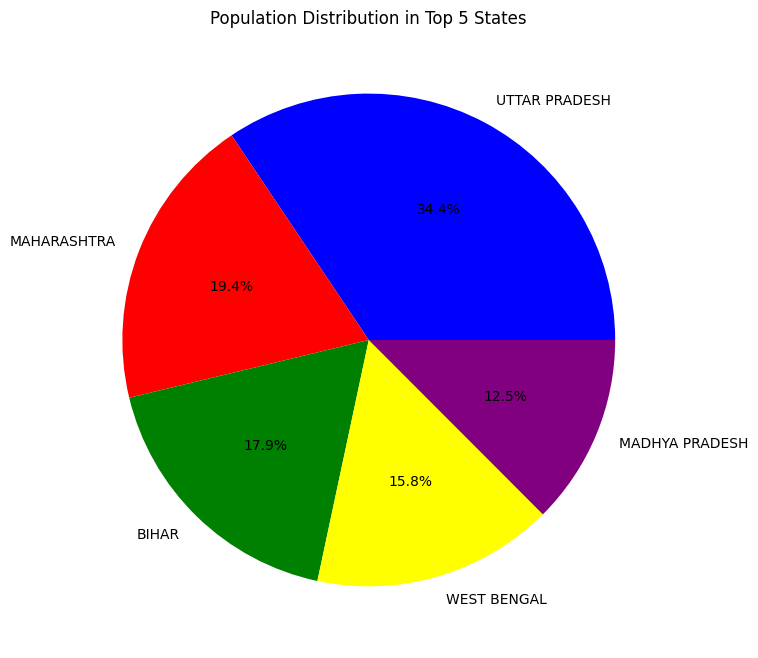

In [24]:
state_population = df_edu.groupby("STATNAME")["TOTPOPULAT"].sum().nlargest(5)  # Top 5 states

plt.figure(figsize=(8, 8))
plt.pie(state_population, labels=state_population.index, autopct="%1.1f%%", colors=['blue', 'red', 'green', 'yellow', 'purple'])

plt.title("Population Distribution in Top 5 States")
plt.show()


#### *`Scatter plot:`*

## **Relationship between total schools and total population.**

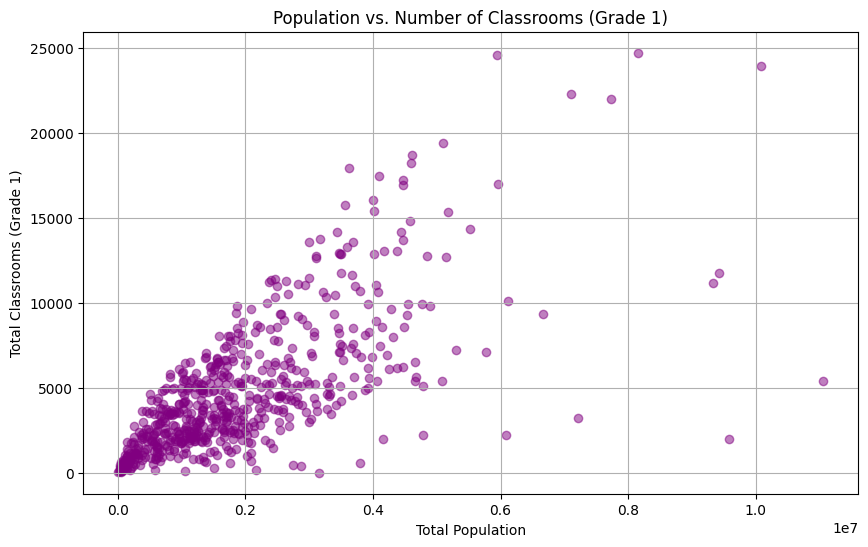

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(df_edu["TOTPOPULAT"], df_edu["TOTCLS1G"], color='purple', alpha=0.5)

plt.xlabel("Total Population")
plt.ylabel("Total Classrooms (Grade 1)")
plt.title("Population vs. Number of Classrooms (Grade 1)")
plt.grid(True)
plt.show()

#### *`Line graph:`*

### **School enrollments over academic years:**

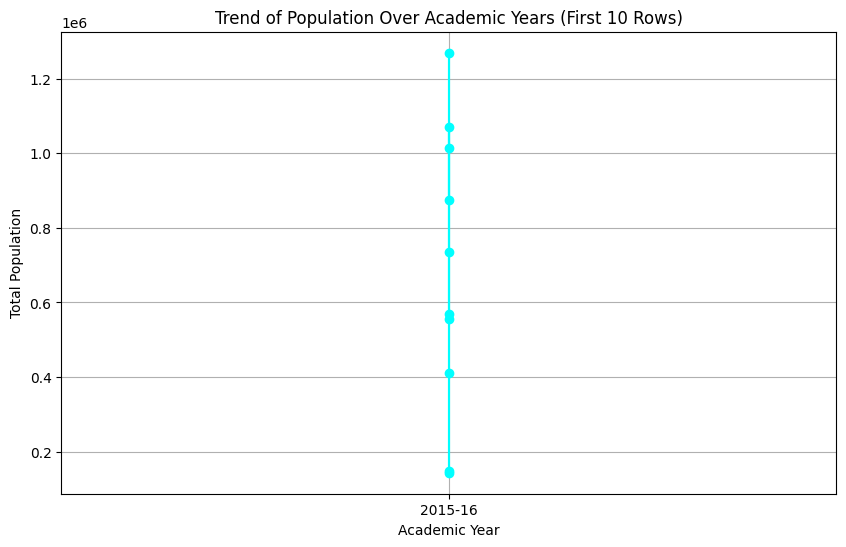

In [32]:
rows = df_edu.head(10)  
plt.figure(figsize=(10, 6))  
plt.plot(rows["AC_YEAR"],rows["TOTPOPULAT"], marker='o', linestyle='-', color='cyan')


plt.xlabel("Academic Year")
plt.ylabel("Total Population")
plt.title("Trend of Population Over Academic Years (First 10 Rows)")
plt.grid(True)  

plt.show()  


#### *`Box plot:`*

## **FOR TOTAL POPULATION:**

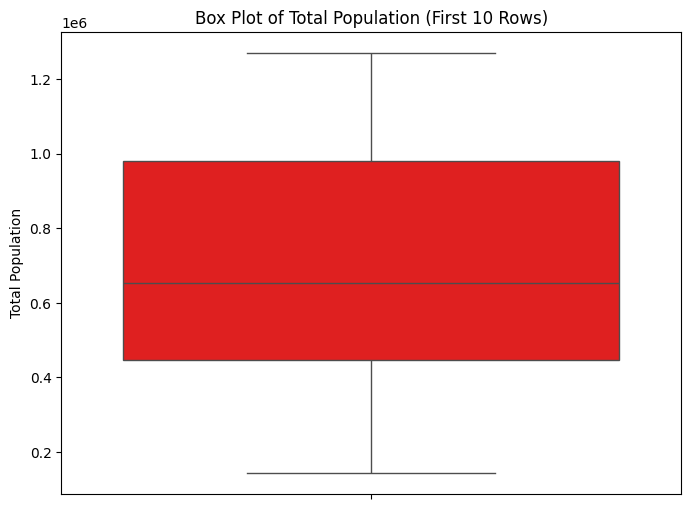

In [36]:
rows = df_edu.head(10)

plt.figure(figsize=(8, 6))
sns.boxplot(y=rows["TOTPOPULAT"], color='red')

plt.title("Box Plot of Total Population (First 10 Rows)")
plt.ylabel("Total Population")

plt.show()


#### *`Ogive Plot:`*

## **FOR TOTAL POPULATION:**

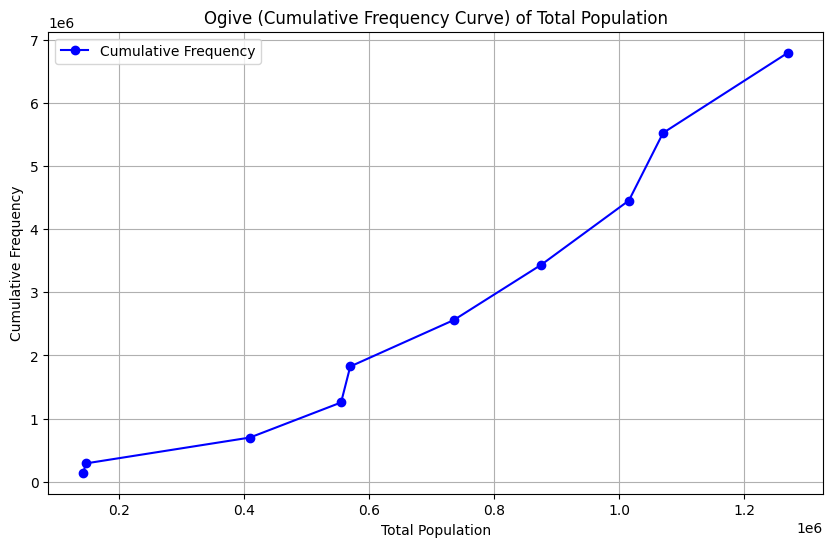

In [37]:
rows = df_edu.head(10)
rows = rows.sort_values("TOTPOPULAT")
cumulative_frequency = np.cumsum(rows["TOTPOPULAT"])

plt.figure(figsize=(10, 6))
plt.plot(rows["TOTPOPULAT"], cumulative_frequency, marker='o', linestyle='-', color='blue', label="Cumulative Frequency")

plt.xlabel("Total Population")
plt.ylabel("Cumulative Frequency")
plt.title("Ogive (Cumulative Frequency Curve) of Total Population")
plt.legend()
plt.grid(True)

plt.show()


#### *`Dot plot:`*

## **For first 10 rows**

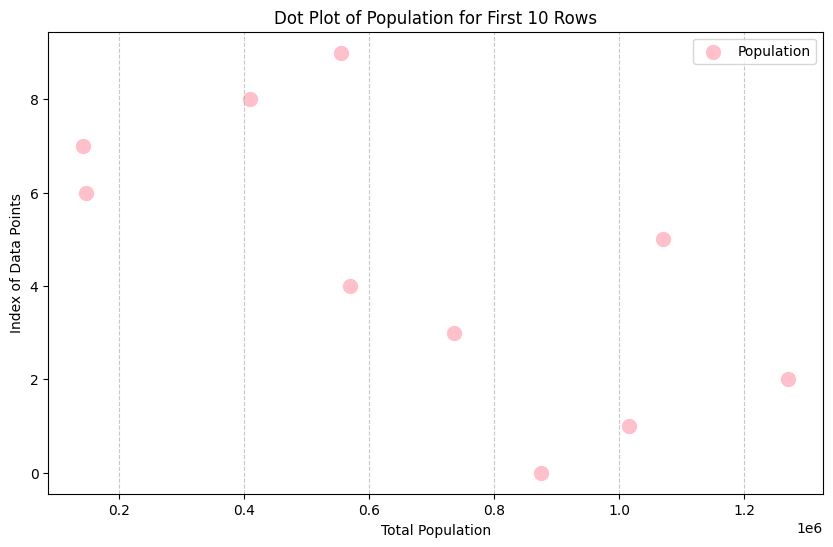

In [43]:
rows = df_edu.head(10)
populations = rows["TOTPOPULAT"]

# Create Y positions (to avoid dots overlapping)
y_positions = np.arange(len(populations))  # Generates 0,1,2,...,9

plt.figure(figsize=(10, 6))
plt.scatter(populations, y_positions, color='pink', s=100, marker='o', label="Population")

plt.xlabel("Total Population")
plt.ylabel("Index of Data Points")
plt.title("Dot Plot of Population for First 10 Rows")

plt.grid(axis='x', linestyle="--", alpha=0.7)
plt.legend()

plt.show()


#### *`Frequency polgon`*

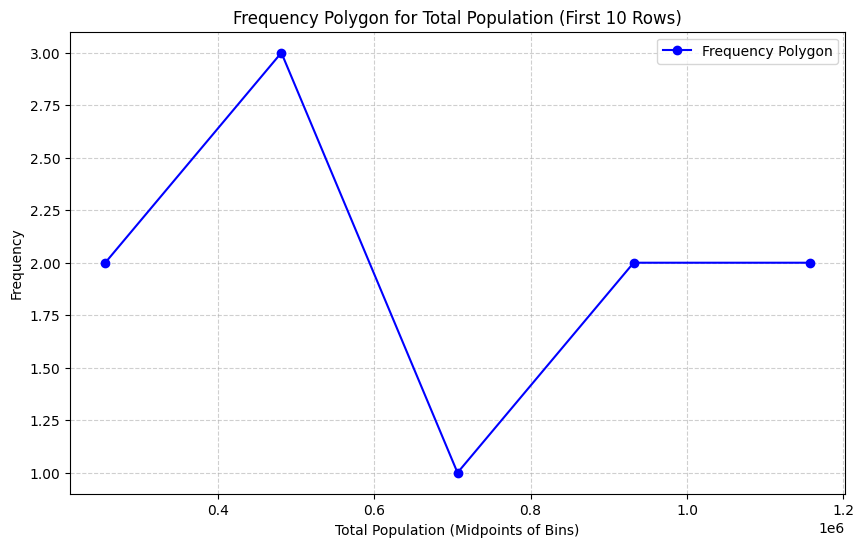

In [44]:
rows = df_edu.head(10)
populations = rows["TOTPOPULAT"]

bins = np.histogram_bin_edges(populations, bins=5)
hist, bin_edges = np.histogram(populations, bins=bins)

midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2

plt.figure(figsize=(10, 6))
plt.plot(midpoints, hist, marker='o', linestyle='-', color='blue', label="Frequency Polygon")

plt.xlabel("Total Population (Midpoints of Bins)")
plt.ylabel("Frequency")
plt.title("Frequency Polygon for Total Population (First 10 Rows)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()


# **Compute Descriptive Statistics**

### *`Measures of Central Tendency:`*

In [48]:
df_stats = df_edu.head(10)
data = df_stats["TOTPOPULAT"]
mean_value = data.mean()  
median_value = data.median()  
mode_value = data.mode().values  

print(f"Mean: {mean_value}")
print(f"Median: {median_value}")
print(f"Mode: {mode_value}")

Mean: 679220.0
Median: 652906.5
Mode: [ 143388.  147104.  409576.  555357.  570060.  735753.  875564. 1015503.
 1070144. 1269751.]


### *`Compute Quartiles & Percentile`*

In [51]:
df_stats = df_edu.head(10)
data = df_stats["TOTPOPULAT"]
Q1 = data.quantile(0.25)  
Q2 = data.quantile(0.50)  
Q3 = data.quantile(0.75)  
IQR = Q3 - Q1  
print(f"Interquartile(Q3 - Q1): {IQR}")

percentile_10 = data.quantile(0.10)  
percentile_90 = data.quantile(0.90)
print(f"Q1 (25th Percentile): {Q1}")
print(f"Q2 (50th Percentile / Median): {Q2}")
print(f"Q3 (75th Percentile): {Q3}")
print(f"10th Percentile: {percentile_10}")
print(f"90th Percentile: {percentile_90}")

Interquartile(Q3 - Q1): 534497.0
Q1 (25th Percentile): 446021.25
Q2 (50th Percentile / Median): 652906.5
Q3 (75th Percentile): 980518.25
10th Percentile: 146732.4
90th Percentile: 1090104.7


### *`Measure of Variability(dispersion);`*

In [50]:
range = data.max() - data.min()
print('Range:',range)
variance = data.var()
print('Variance:',variance)
std_dev= data.std()
print("Standard deviation:",std_dev)
iqr_value = data.quantile(0.75) - data.quantile(0.25)
print("Interquartile value:",iqr_value)


Range: 1126363.0
Variance: 147401204781.77777
Standard deviation: 383928.64543008216
Interquartile value: 534497.0


### *`Measure of Shape(skewness & kurtosis):`*

In [52]:
skewness = data.skew()  
kurtosis= data.kurt() 
print('Skewness:',skewness)
print('Kurtosis:',kurtosis)

Skewness: -0.03893623696564862
Kurtosis: -1.0492545785601721


# **<u>RESULTS INTERPRETATION & FINDINGS:<u>**

### -The data for the first 10 rows shows a (normal/skewed) distribution based on the mean, median, and histogram.
Skewness: -0.03 (Approximately Symmetrical)

Since skewness is close to 0, the data is almost symmetric.

The distribution has lighter tails than a normal distribution.

Data is more evenly spread rather than concentrated around the mean.

### -IQR & standard deviation indicate whether the data is closely packed or widely spread.

### -Box plots help detect outliers, while scatter plots reveal possible relationships between variables

The box is centered, confirming no significant skew.

No extreme outliers detected.

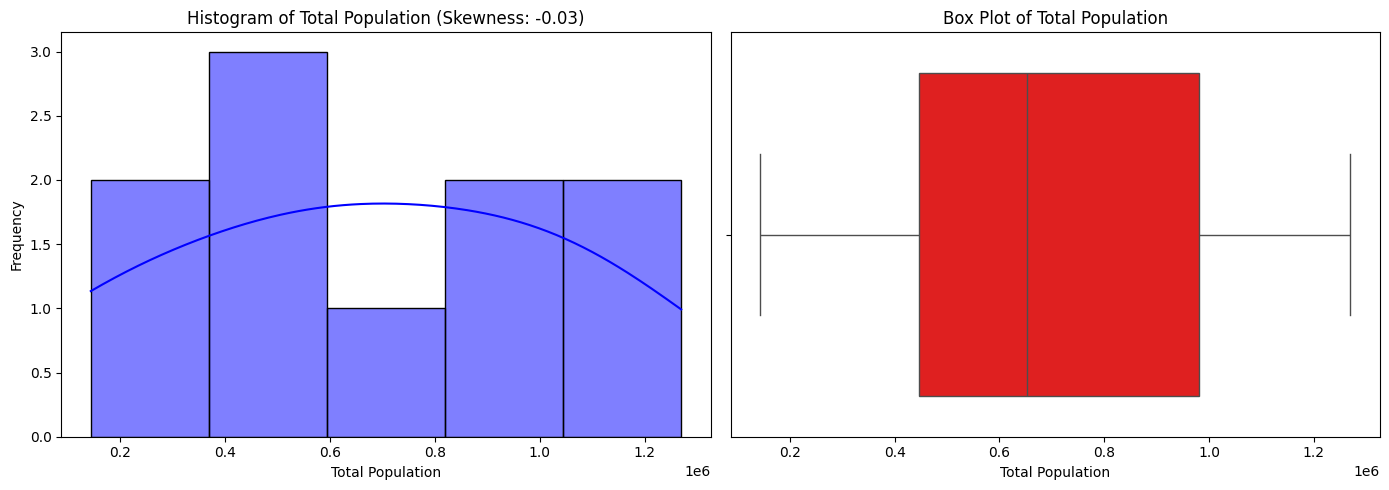

Skewness: -0.03
Kurtosis: -1.14


In [56]:
from scipy.stats import skew, kurtosis
df_top10 = df_edu.head(10)
data = df_top10["TOTPOPULAT"]

data_skewness = skew(data)
data_kurtosis = kurtosis(data)

# Create subplots for Histogram and Box Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with Skewness
sns.histplot(data, bins=5, kde=True, color="blue", ax=axes[0])
axes[0].set_title(f"Histogram of Total Population (Skewness: {data_skewness:.2f})")
axes[0].set_xlabel("Total Population")
axes[0].set_ylabel("Frequency")

# Box Plot (Detecting Outliers & Shape)
sns.boxplot(x=data, color="red", ax=axes[1])
axes[1].set_title("Box Plot of Total Population")
axes[1].set_xlabel("Total Population")


plt.tight_layout()
plt.show()